In [3]:
# Torch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
import grid_simulation

import numpy as np

from torch import multiprocessing

%reload_ext autoreload
%autoreload 2

from cuda_square_simulation import SquareSimulation

# Utils
torch.manual_seed(0)
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm

In [4]:
def clever_single_action(env, action_batch, obs_indices):
    if action_batch is None:
        return None
    
    # By default, random actions
    # Pop 0 is random
    # Pop 1 is semi-random
    # Pop 2 is random
    actions = env.configurable_actions_grid(None, 'attacking', 'attacking')
    
    batch_idx, x_idx, y_idx = obs_indices.T

    # Now assign:
    # 0: move to clever
    actions[batch_idx, x_idx, y_idx] = action_batch.float()
    
    return actions

# Unstable REINFORCE

In [5]:
device = (
    torch.device(0)
    if torch.cuda.is_available()
    else torch.device("cpu")
)

print(f"Using device: {device}")

lr = 1e-3
max_grad_norm = 0.01

Using device: cuda:0


In [6]:
# Define the observation shape as returned by get_deep_observations.
# For example, if your simulation returns patches of shape (C, obs_size, obs_size)
# and C = number_of_populations (say 3) and obs_size is 5:
obs_shape = (3, 5, 5)

from torch.nn.utils import weight_norm


# Simple policy network for a discrete action space (0 to 16):
import torch.nn.functional as F
from torch.nn.utils import spectral_norm

class PolicyNet(nn.Module):
    def __init__(self, obs_dim, hidden_dim, n_actions):
        super().__init__()
        self.fc1 = spectral_norm(nn.Linear(obs_dim, hidden_dim))
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(hidden_dim, n_actions)

    def forward(self, x):
        # (optional) input check omitted for brevity
        x = x.view(x.size(0), -1)
        z = self.fc1(x)
        x = F.relu(z)

        x = self.dropout(x)

        logits = self.fc2(x)

        # final safety: make it a valid distribution
        probs = F.softmax(logits, dim=-1).clamp(min=1e-8, max=1-1e-8)
        return probs

    def __init__(self, obs_shape, num_actions=17):        
        super().__init__()
        
        self.saved_log_probs = []
        self.rewards = []
        self.exploration_importance = 1
        self.observation_indices = []

        self.saved_entropies = []
        
        self.all_rewards = []
        self.all_losses = []
        self.action_counts = [0] * num_actions
        
        C, H, W = obs_shape
        # Flatten the observation
        self.flatten = nn.Flatten()
        self.fc1 = weight_norm(nn.Linear(C * H * W, 100))

        self.dropout = nn.Dropout(p=0.2)

        self.fc2 = weight_norm(nn.Linear(100, num_actions))
        
    def forward(self, x):
        # x shape: (batch, C, H, W)
        if torch.isnan(x).any():
            print("NaN in x before flatten")
            print(x)
            raise ValueError("NaN in x before flatten")

        x = x.view(x.size(0), -1)  # Flatten the input

        if torch.isnan(x).any():
            print("NaN in x before fc1")
            print(x)
            raise ValueError("NaN in x before fc1")

        x = torch.relu(self.fc1(x))

        if torch.isnan(x).any():
            print("NaN in x after fc1")
            print(x)
            raise ValueError("NaN in x after fc1")

        x = self.dropout(x)  # Apply dropout

        if torch.isnan(x).any():
            print("NaN in x after fc1 + dropout")
            print(x)
            raise ValueError("NaN in x after fc1 + dropout")

        logits = self.fc2(x)

        # Check nan
        if torch.isnan(logits).any():
            print("NaN in logits")
            print(x)
            print(logits)
            raise ValueError("NaN in logits")

        probs = F.softmax(logits, dim=-1).clamp(min=1e-8, max=1-1e-8)  # Convert logits to probabilities

        return probs

# Create the policy and the corresponding optimizer:
policy_net = PolicyNet(obs_shape).to(device)
optimizer = optim.Adam(policy_net.parameters(), lr, weight_decay=1e-4)

/home/delsad/SHS-Life-Science-Philosophy-Altruism/grid_simulation/cuda_env_project/.pixi/envs/default/lib/python3.13/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


In [7]:
nb_batches = 100
rows, cols = 20, 20
populations = {
    "red": {"p": 0.2, "mean_v": 1.0, "std_v": 0.2},
    "blue": {"p": 0.2, "mean_v": 1.0, "std_v": 0.2},
    "green": {"p": 0.2, "mean_v": 1.0, "std_v": 0.2},
}

gamma = 0.98

clever_pop_id = 0  # Clever population ID

simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols, populations=populations, device=device)
simulation.reset()

In [8]:
from collections import defaultdict
from itertools import accumulate

def select_action(observations):
    if observations.size(0) == 0:
        return None

    probs = policy_net(observations).clamp(min=1e-6, max=1.0-1e-6)     # shape: (batch, n_actions)

    if torch.any(torch.isnan(probs)):
        print("NaN in probs")
        return None

    m     = Categorical(probs)

    action = m.sample()                  # shape: (batch,)
    policy_net.saved_log_probs.append(m.log_prob(action))  # for PG loss
    policy_net.saved_entropies.append(m.entropy())

    # optional: track counts for diagnostics
    unique, counts = torch.unique(action, return_counts=True)
    for u, c in zip(unique.tolist(), counts.tolist()):
        policy_net.action_counts[u] += c / 10000

    return action


from collections import defaultdict

def finish_episode(policy_net, optimizer, gamma=0.99, max_grad_norm=1.0):
    if not policy_net.saved_log_probs:
        return

    device = policy_net.saved_log_probs[0].device
    T      = len(policy_net.rewards)

    # ---------- 2.1  gather all agent‑ids once, build mapping ----------
    # cat →  (∑_t n_t, 3)
    flat_ids      = torch.cat(policy_net.observation_indices, dim=0)
    # unique over rows gives:  unique_ids … (N,3),  inverse_map … (∑_t n_t,)
    unique_ids, inverse_map = torch.unique(flat_ids,
                                           return_inverse=True,
                                           dim=0)
    N_agents = unique_ids.size(0)

    # how many agents appear at each timestep?
    lens   = torch.tensor([ids.size(0) for ids in policy_net.observation_indices],
                          device=device)                                # (T,)
    # cumulative lengths let us slice inverse_map without Python loops
    # ptr[t] = start index for timestep t inside inverse_map
    ptr = torch.cat((lens.new_zeros(1), lens.cumsum(0)), dim=0)         # (T+1,)

    running_return = torch.zeros(N_agents, device=device)
    returns        = [None] * T            # will fill from back to front

    # ---------- 2.2  backwards pass over timesteps (no inner loop) ----
    for t in range(T - 1, -1, -1):
        idx_slice   = inverse_map[ptr[t]:ptr[t+1]]      # (n_t,)  long / int64
        step_return = policy_net.rewards[t].to(torch.float32)

        # vectorised Bellman update:
        #   R_a ← r_t(a) + γ·R_a     ∀ agents present at this timestep
        running_return.index_put_((idx_slice,),
                                  step_return + gamma * running_return[idx_slice],
                                  accumulate=False)

        returns[t] = running_return[idx_slice]           # (n_t,)

    # ---------- 2.3  flatten, standardise, loss -----------------------
    flat_returns   = torch.cat(returns,        dim=0)             # matches order
    flat_log_probs = torch.cat(policy_net.saved_log_probs, dim=0)

    # --- flatten the saved entropies ---
    flat_entropies = torch.cat(policy_net.saved_entropies, dim=0)

    # --- standardize returns as before ---
    flat_returns = (flat_returns - flat_returns.mean()) / (flat_returns.std(unbiased=False).clamp(min=1e-6))

    # --- combine PG loss with entropy bonus ---
    pg_loss      = -(flat_log_probs * flat_returns).sum()
    entropy_loss = -policy_net.exploration_importance * flat_entropies.sum()    # note the minus: we want to *maximize* entropy
    policy_loss  = pg_loss + entropy_loss

    policy_net.exploration_importance *= 0.99


    # ---------- 2.4  optimise ----------------------------------------
    optimizer.zero_grad(set_to_none=True)
    policy_loss.backward()
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), max_grad_norm)
    optimizer.step()

    # ---------- 2.5  bookkeeping -------------------------------------
    policy_net.all_losses.append(policy_loss.item())
    episode_return = sum(r.sum().item() for r in policy_net.rewards)
    policy_net.all_rewards.append(episode_return)

    policy_net.rewards.clear()
    policy_net.saved_log_probs.clear()
    policy_net.observation_indices.clear()
    policy_net.saved_entropies.clear()


In [9]:
learn_steps = 10
nb_epochs = 45


for i_episode in tqdm(range(nb_epochs)):
    simulation.reset()
    ep_reward = 0
    
    # print(f"Episode {i_episode} - Time 0.")
    # plt.figure(dpi=20)
    # grid_simulation.run_visual_simulation_grid(simulation)
    
    for t in tqdm(range(750), leave=False):
        with torch.no_grad():
            observations, obs_indices = simulation.get_deep_observations(clever_pop_id)
        
        action = select_action(observations)

        with torch.no_grad():
            all_actions_grid = clever_single_action(simulation, action, obs_indices) 
            
            rewards, done, info = simulation.step(all_actions_grid, obs_indices)
            
            # print(f"Episode {i_episode} - Time {t} - Reward: {rewards[clever_pop_id]:.4f} - Done: {done} - Action: {action is None}")
            # print("Number of clever pop:", (simulation.grid[:, clever_pop_id] > simulation.EPS).sum().item())
        
        # clever_pop_rewards = rewards
        # clever_pop_rewards = clever_pop_rewards / nb_batches
        clever_pop_rewards = rewards
        
        policy_net.rewards.append(clever_pop_rewards)
        policy_net.observation_indices.append(obs_indices.detach().cpu())
        ep_reward += clever_pop_rewards.mean().item()
        
        if t % learn_steps == 0 and t > 0:
            # Update the policy every 50 steps           
            finish_episode(policy_net, optimizer)
            
    print(f"Episode {i_episode} - Time {t} - Avg reward: {ep_reward:.4f} - Loss: {policy_net.all_losses[-1]:.2f} - Action counts: {100 *np.array(policy_net.action_counts) / np.sum(policy_net.action_counts)}")
    # plt.figure(dpi=20)
    # grid_simulation.run_visual_simulation_grid(simulation)

  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/750 [00:00<?, ?it/s]

Episode 0 - Time 749 - Avg reward: -99.5420 - Loss: -365720.66 - Action counts: [7.0274631  5.88651122 5.90789408 5.93802379 5.9194432  5.91311746
 5.86540652 5.94651306 5.88184418 5.64597328 5.78619049 5.67150291
 5.75326881 5.69551807 5.79549881 5.60023012 5.76560092]


  0%|          | 0/750 [00:00<?, ?it/s]

Episode 1 - Time 749 - Avg reward: -95.0962 - Loss: -183102.41 - Action counts: [8.60907443 5.73412198 5.67310195 5.76484004 5.72675973 5.72601077
 5.6881151  5.72278345 5.69932881 5.6491376  5.8645099  5.44783444
 5.82725138 5.67317477 5.93421066 5.38757118 5.87217381]


...

Episode 42 - Time 749 - Avg reward: -10.3096 - Loss: -39.22 - Action counts: [77.48546371  1.36553876  1.38530414  1.40816657  1.37099385  1.37011572
  1.36104645  1.38344184  1.37226457  1.44621742  1.52893256  1.23122968
  1.53272431  1.48126853  1.57802056  1.2186873   1.48058403]


  0%|          | 0/750 [00:00<?, ?it/s]

Episode 43 - Time 749 - Avg reward: -7.3620 - Loss: -27.22 - Action counts: [77.51916767  1.36346822  1.38320152  1.4060796   1.36904274  1.3680688
  1.35903473  1.38142269  1.37031105  1.44402192  1.52661093  1.22936053
  1.53039933  1.47901521  1.57562602  1.21683631  1.47833272]


  0%|          | 0/750 [00:00<?, ?it/s]

Episode 44 - Time 749 - Avg reward: -10.0425 - Loss: -0.96 - Action counts: [77.55810053  1.36107768  1.38077758  1.40366276  1.36674612  1.36569681
  1.35670682  1.37909547  1.36813972  1.44147791  1.52392537  1.22719724
  1.52770465  1.47640841  1.57285774  1.21469466  1.47573052]


In [10]:
# Save the model
torch.save(policy_net.state_dict(), "policy_net.pth")

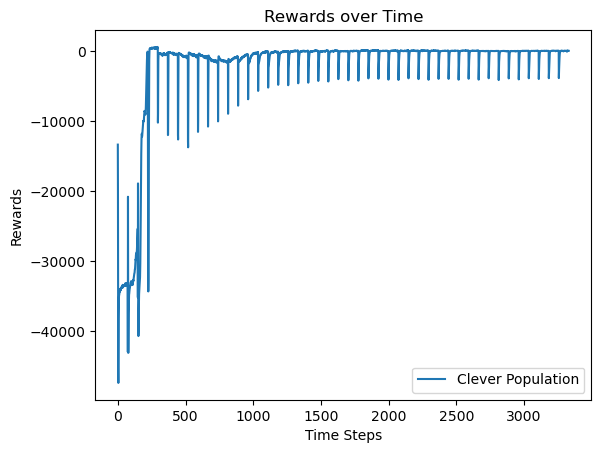

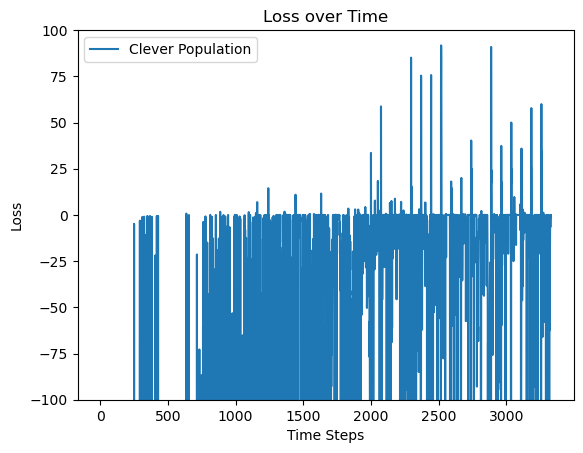

In [11]:
# Plot the rewards
plt.plot(policy_net.all_rewards, label="Clever Population")
plt.xlabel("Time Steps")
plt.ylabel("Rewards")
plt.title("Rewards over Time")
plt.legend()
plt.savefig("rewards.png")
plt.show()

plt.plot(policy_net.all_losses, label="Clever Population")
plt.xlabel("Time Steps")
plt.ylabel("Loss")
plt.title("Loss over Time")
plt.ylim(-100, 100)
plt.legend()

# Visualize

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

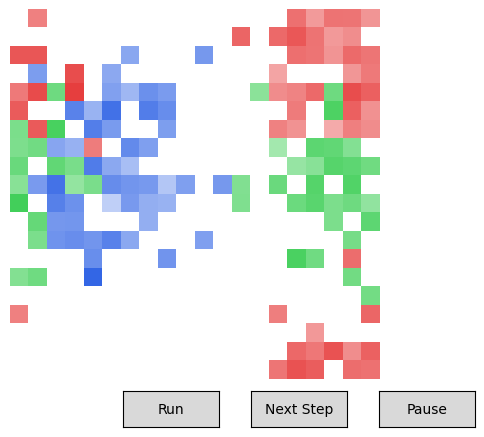

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

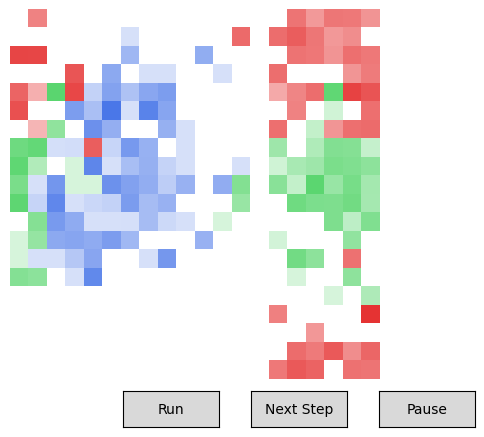

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

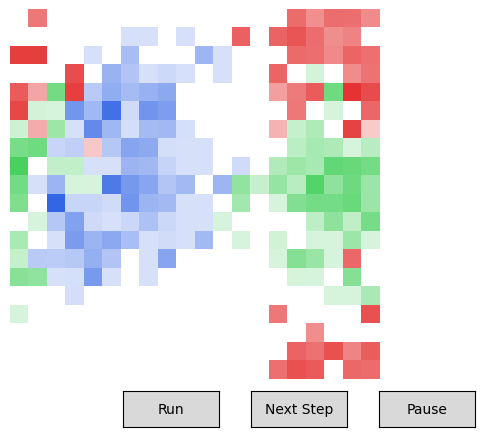

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

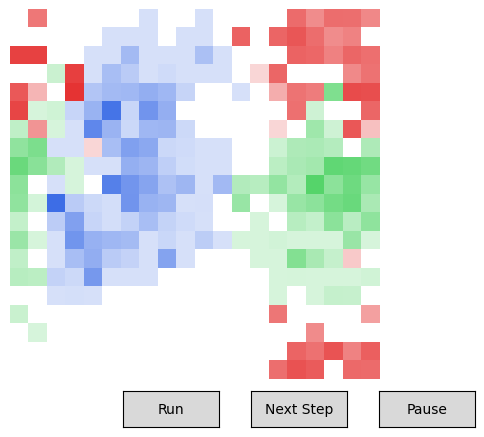

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

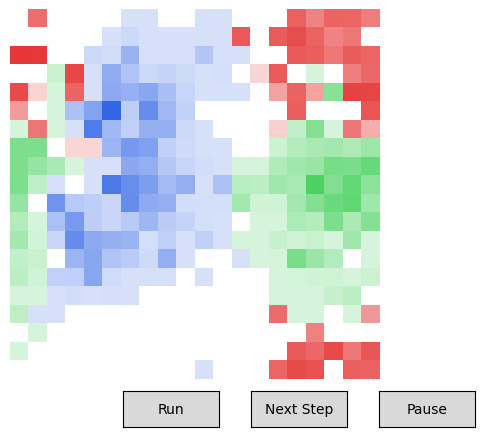

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

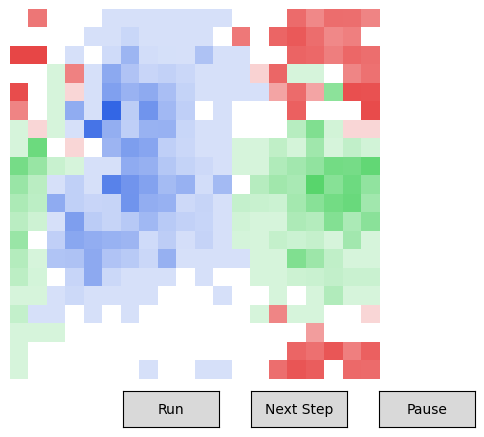

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

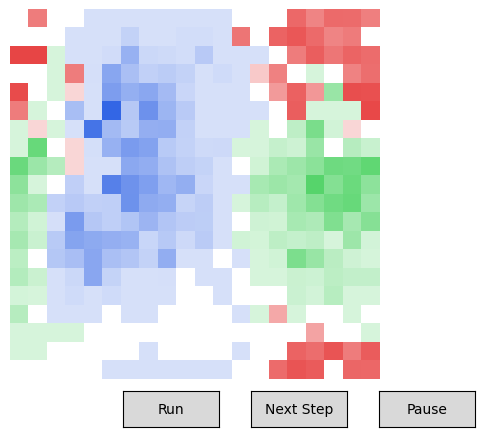

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

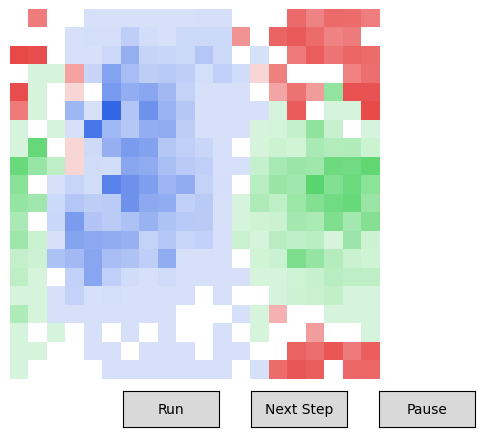

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

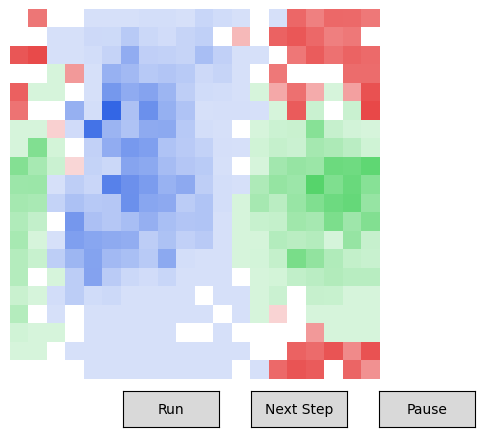

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

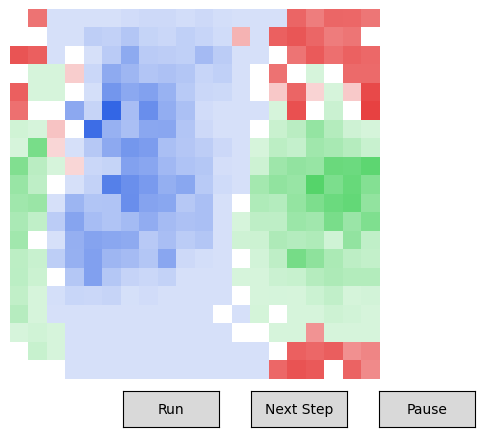

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

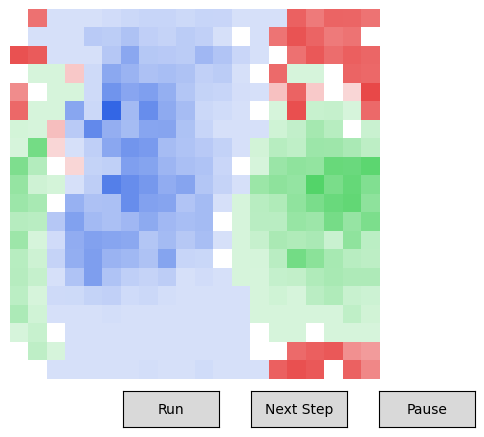

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

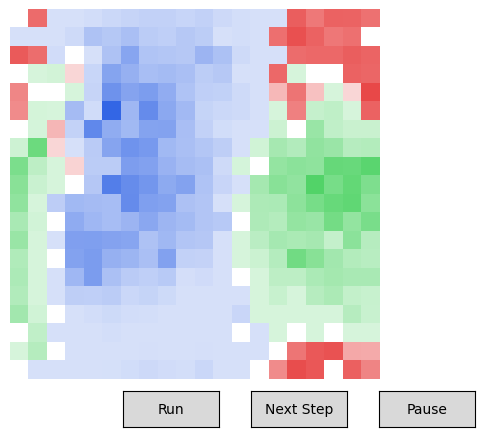

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

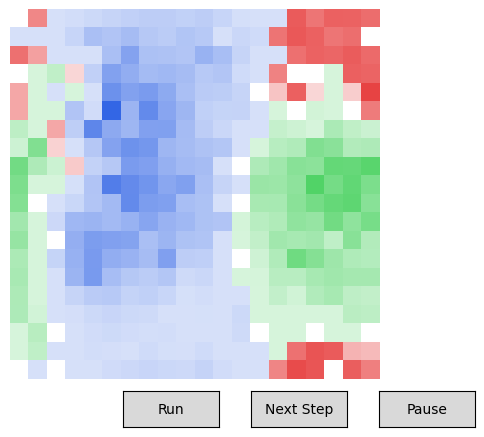

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

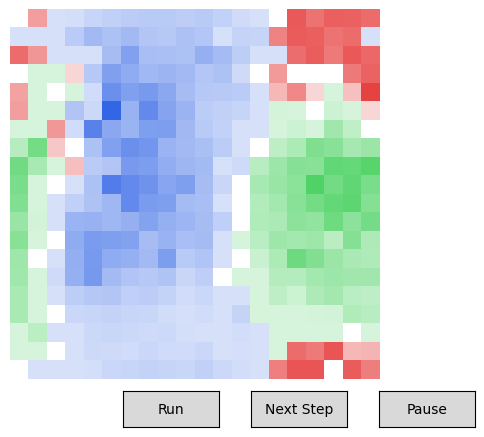

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

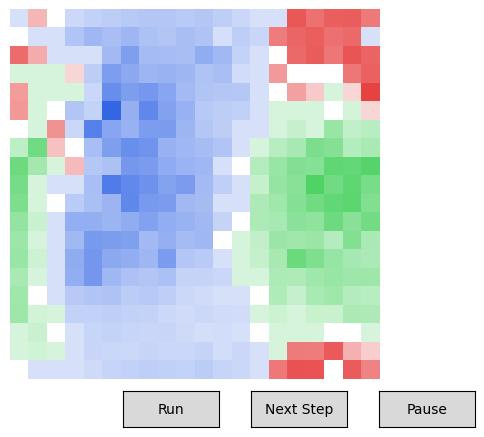

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

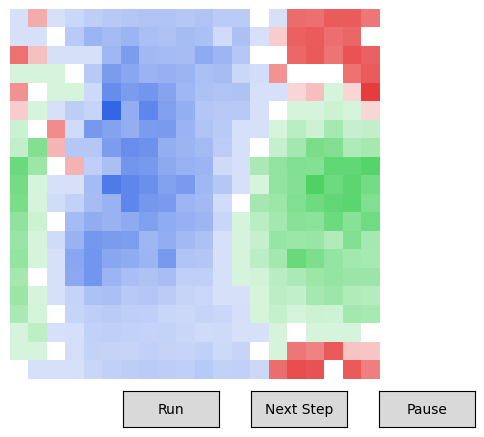

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

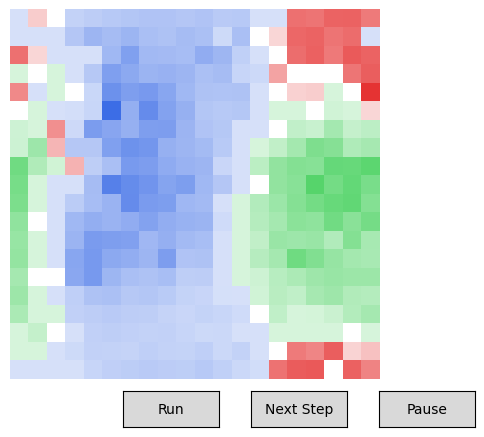

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

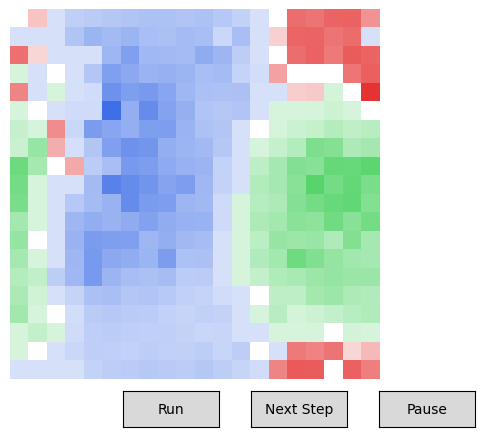

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

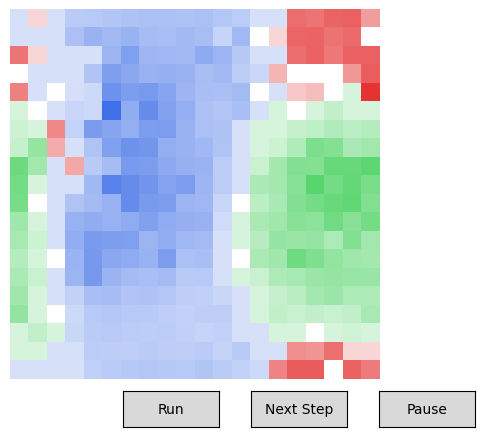

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

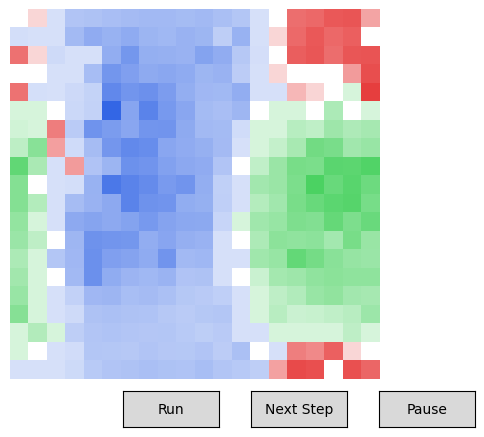

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

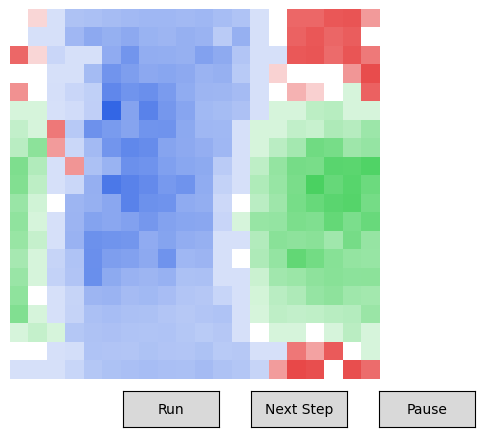

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

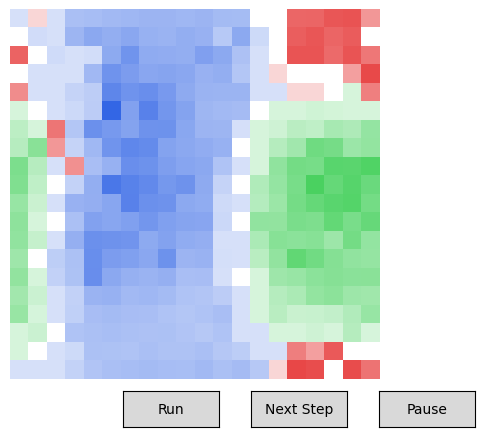

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

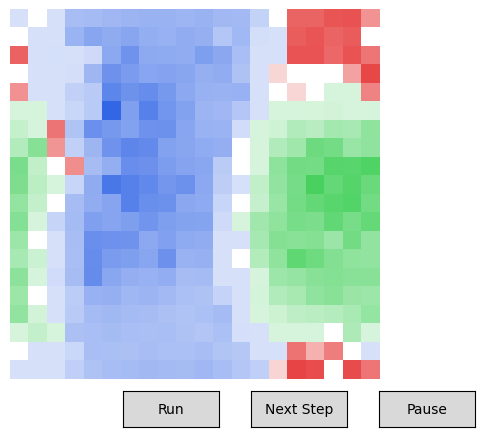

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

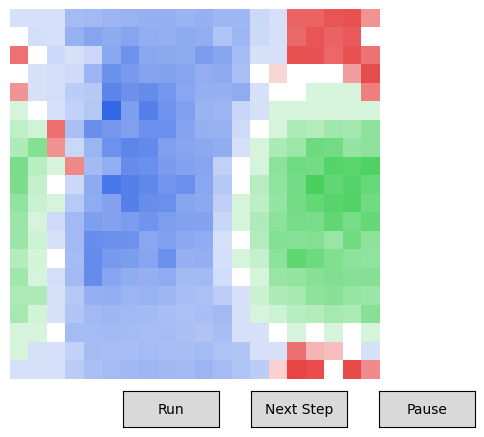

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

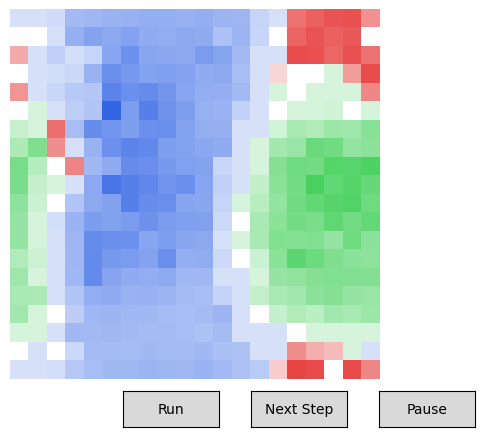

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

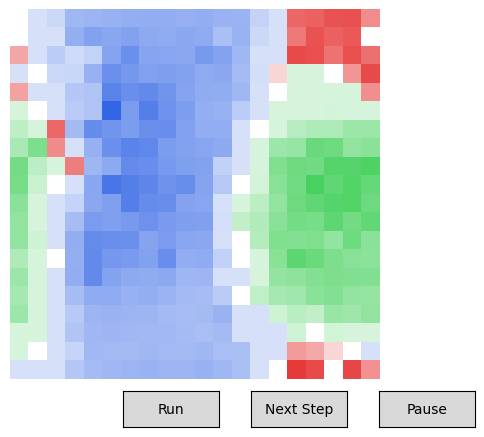

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

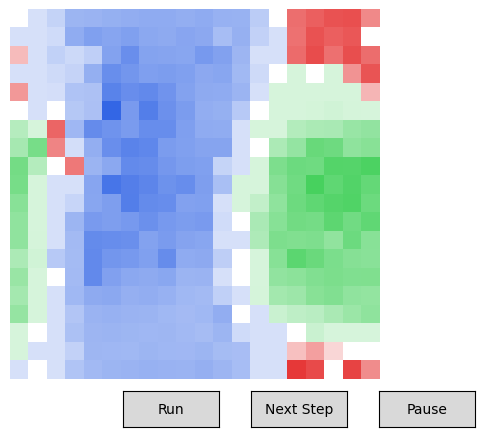

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

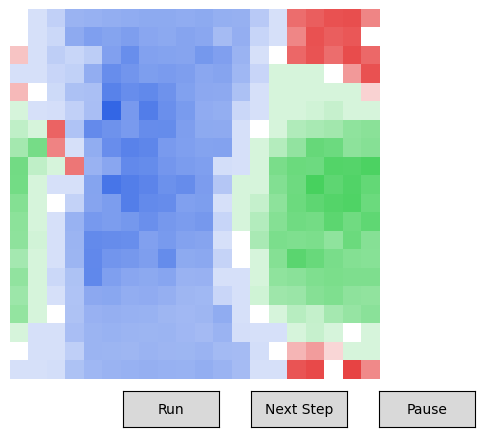

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

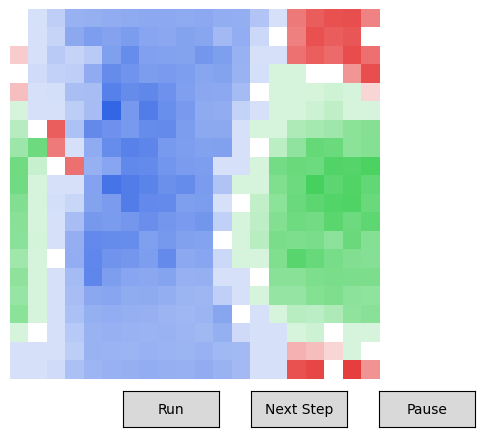

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

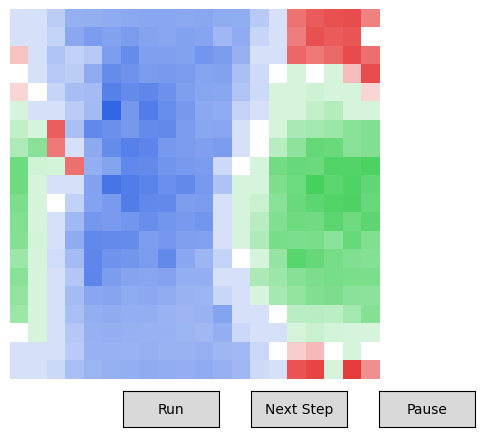

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

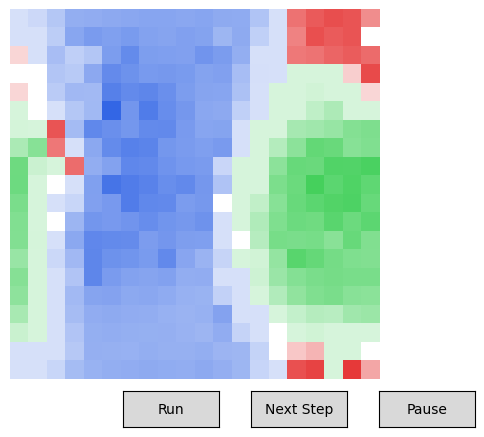

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

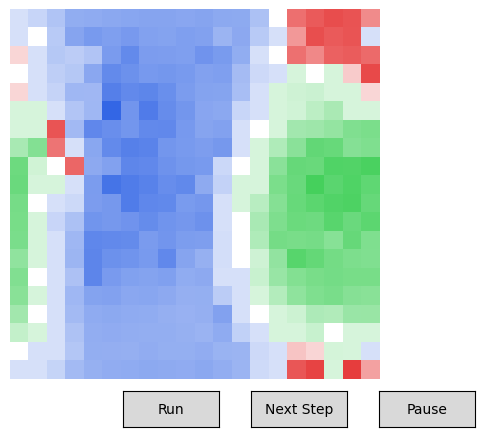

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

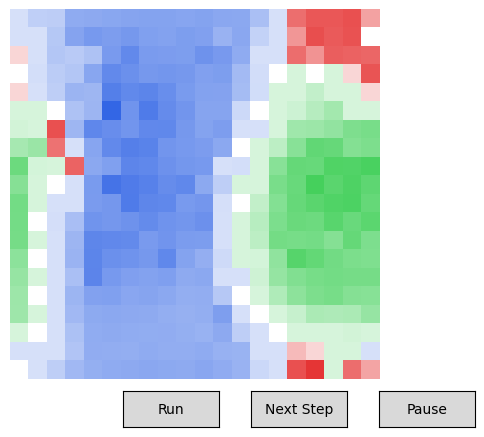

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

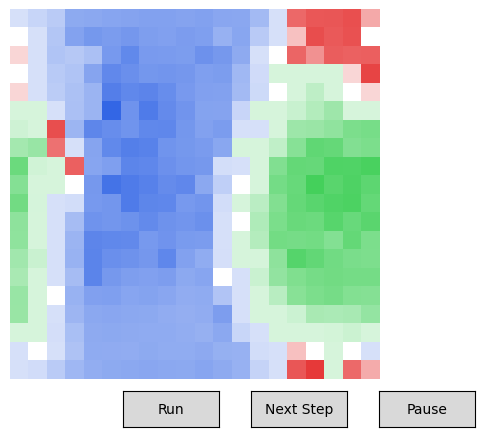

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

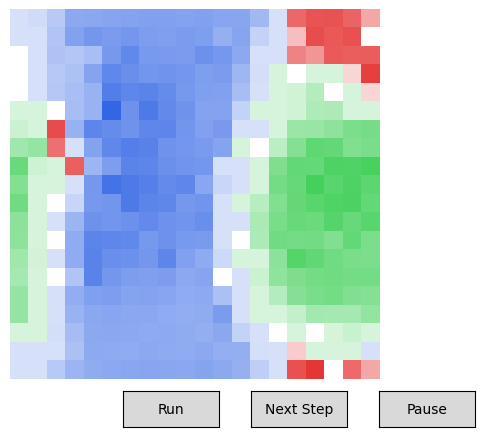

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

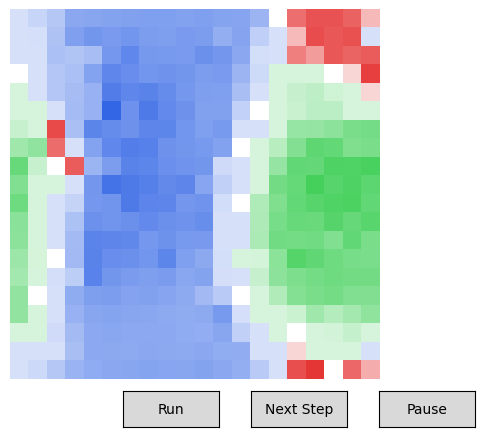

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

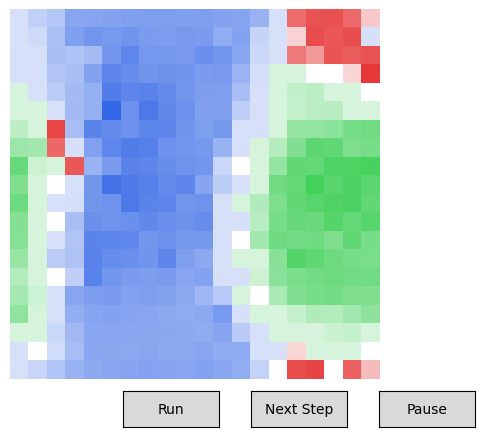

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

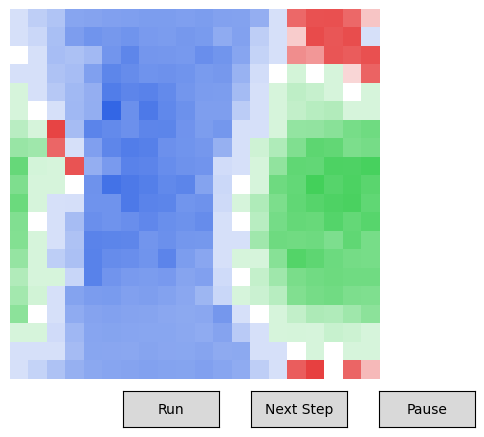

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

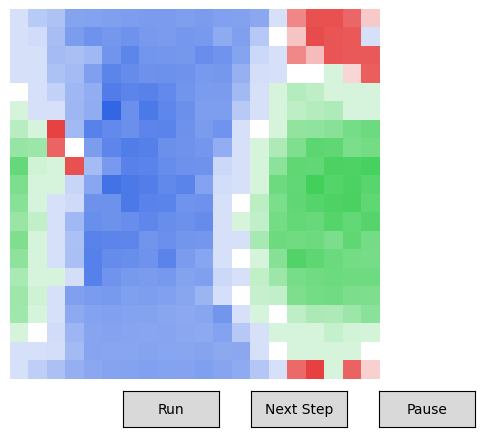

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

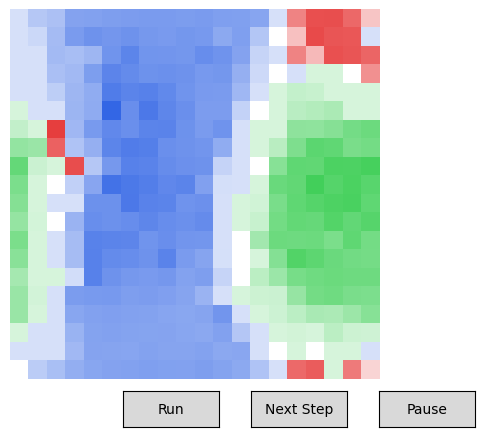

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

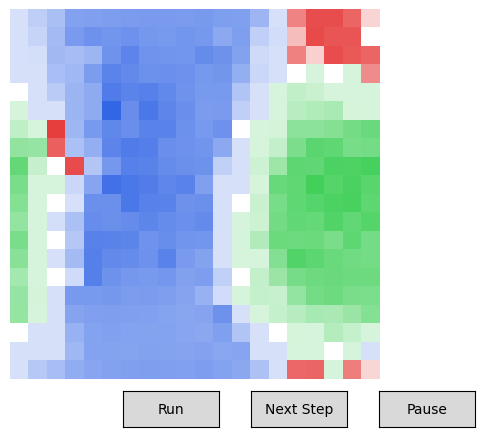

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

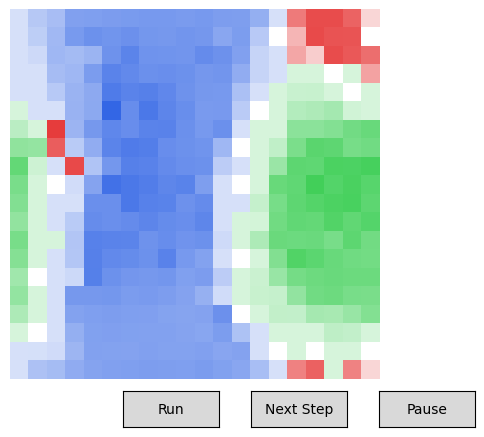

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

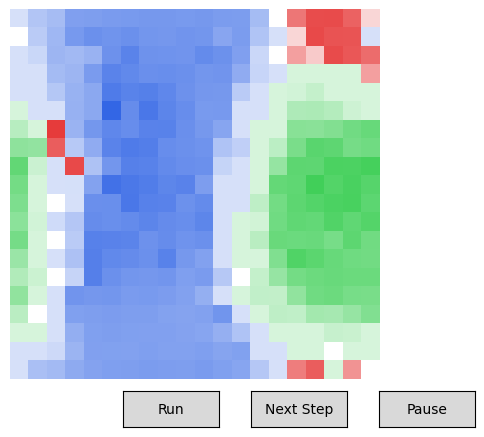

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

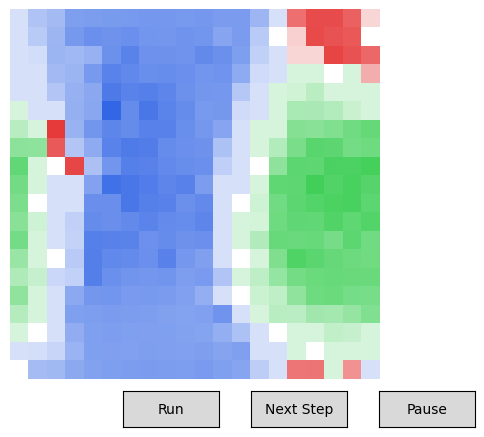

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

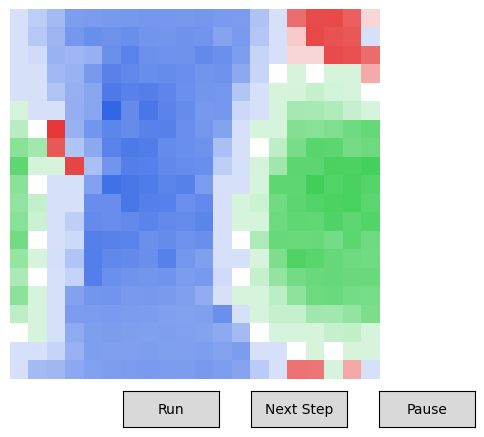

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

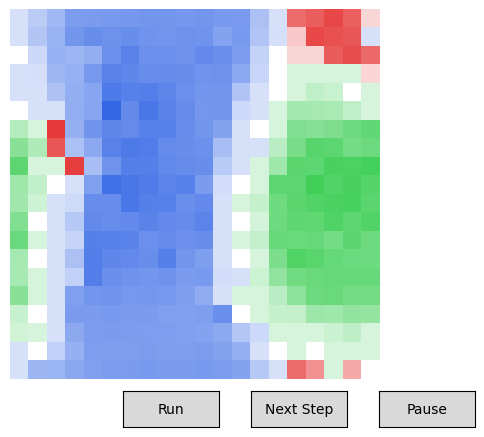

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

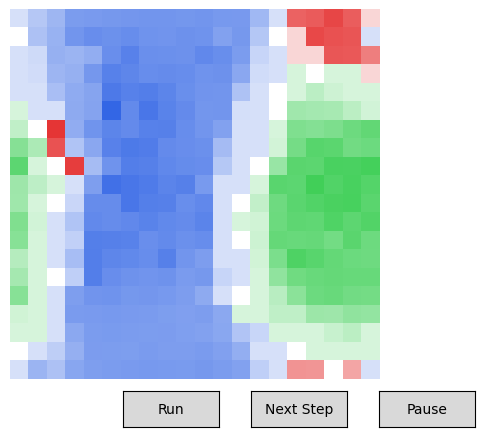

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

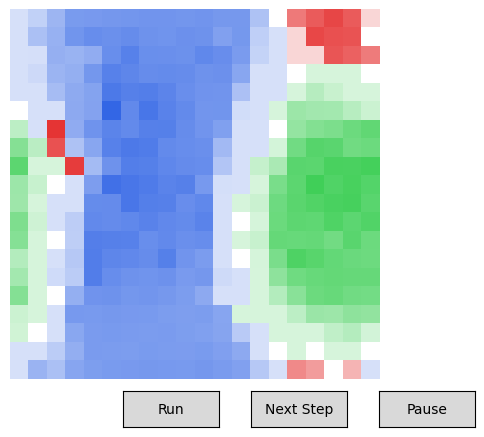

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

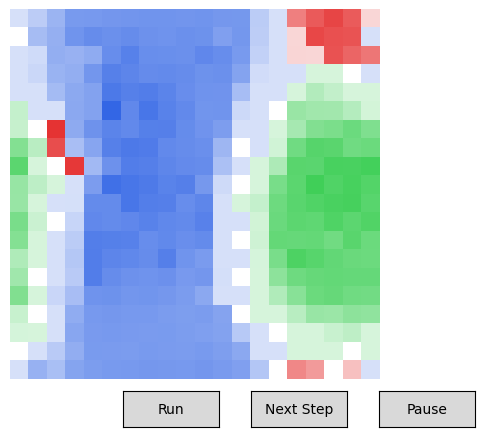

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].


<Figure size 128x96 with 0 Axes>

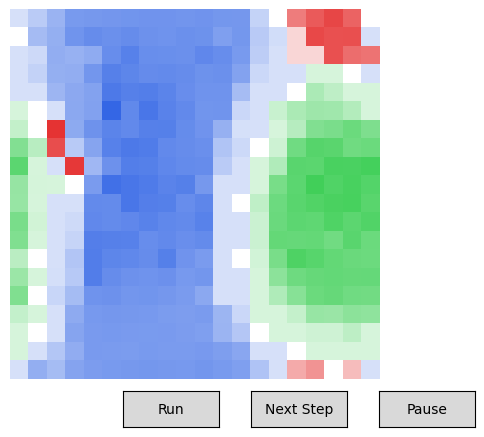

Test reward: -4.4372


In [12]:
env = SquareSimulation(
    nb_batch=1,
    rows=20,
    cols=20,
    populations=populations,
    device=device,
)
env.reset()

def test_policy(env, policy_net, nb_steps=500):
    env.reset()
    ep_reward = 0
    for t in range(nb_steps):
        
        if t % 10 == 0:
            plt.figure(dpi=20)
            grid_simulation.run_visual_simulation_grid(env)

            with torch.no_grad():
                observations, obs_indices = env.get_deep_observations(clever_pop_id)
            
            action = select_action(observations)

            with torch.no_grad():
                all_actions_grid = clever_single_action(env, action, obs_indices) 
                
                rewards, done, info = env.step(all_actions_grid, obs_indices)
                
            clever_pop_rewards = rewards
            clever_pop_rewards = clever_pop_rewards
            ep_reward += clever_pop_rewards.mean().item()
            
    return ep_reward

# Test the policy
test_reward = test_policy(env, policy_net)
print(f"Test reward: {test_reward:.4f}")